# Informes de ventas

Automatización informe de ventas desde archivo excel "ventas"

1. Importar librerías

In [17]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

2. Cargar archivos

In [18]:
df = df1 = pd.read_csv('ventas.csv', sep=',')

3. Visualización dataframe

In [19]:
df

,id,nombre,precio,codigo
0,1,Sustrato cactus y suculentas,8990,A100000000A
1,2,Sustrato para macetas,8990,A100000001A
2,3,Monstera,15000,A100000002A
3,4,Potos,8990,A100000003A
4,5,Lirio de la Paz,5500,A100000004A
5,6,Filodendro,18500,A100000005A
6,7,Violeta,7990,A100000006A
7,8,Rosas,20000,A100000007A
8,9,Manzanilla,3500,A100000008A
9,10,Sustrato cactus y suculentas,8990,A100000000A


4. Datos estadísticos

4.1 Ventas totales

In [20]:
total = df["precio"].sum()
print("Ventas total:", total)

Ventas total: 373810


4.2 Ventas por producto

In [21]:
indices_por_producto = df.groupby("nombre").groups
print(indices_por_producto)

{'Filodendro': [5, 14, 18, 27], 'Lirio de la Paz': [4, 13, 26], 'Manzanilla': [8, 17, 21], 'Monstera': [2, 11, 24], 'Potos': [3, 12, 25], 'Rosas': [7, 16, 20], 'Sustrato cactus y suculentas': [0, 9, 22, 28, 30, 31, 32, 33, 34], 'Sustrato para macetas': [1, 10, 23, 29], 'Violeta': [6, 15, 19]}


In [22]:
claves = list(indices_por_producto.keys())
print(claves)

['Filodendro', 'Lirio de la Paz', 'Manzanilla', 'Monstera', 'Potos', 'Rosas', 'Sustrato cactus y suculentas', 'Sustrato para macetas', 'Violeta']


In [23]:
lista_total_ventas =[]
for elemento in claves:
    indices = indices_por_producto[elemento]

    lista_indices = []
    for i in range(len(indices)):
        valor = indices[i]
        lista_indices.append(valor)

    lista_indices_limpia = [int(x) for x in lista_indices]

    total_ventas = df.iloc[lista_indices_limpia]["precio"].sum()

    lista_total_ventas.append(total_ventas)

lista_total_ventas_limpia = [int(x) for x in lista_total_ventas]
print(lista_total_ventas_limpia)

[74000, 16500, 10500, 45000, 26970, 60000, 80910, 35960, 23970]


In [25]:
df2 = pd.DataFrame({"producto": claves, "ventas total": lista_total_ventas_limpia})
df2

,producto,ventas total
0,Filodendro,74000
1,Lirio de la Paz,16500
2,Manzanilla,10500
3,Monstera,45000
4,Potos,26970
5,Rosas,60000
6,Sustrato cactus y suculentas,80910
7,Sustrato para macetas,35960
8,Violeta,23970


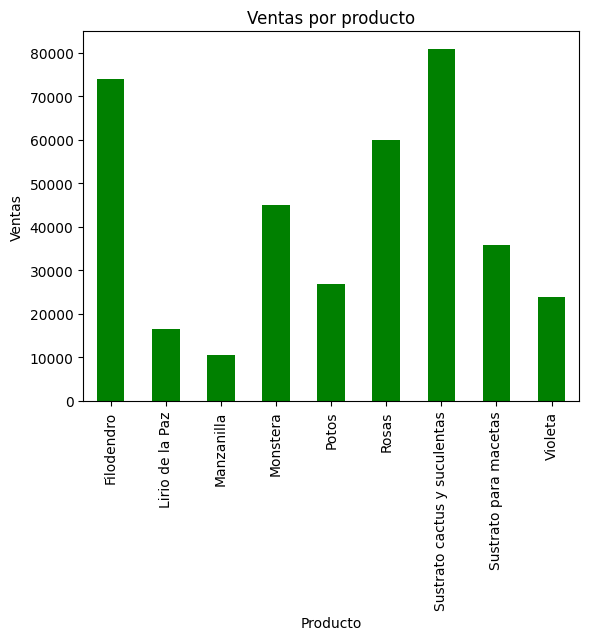

In [26]:
df2.set_index("producto")["ventas total"].plot(kind="bar", color="green")

plt.xlabel("Producto")
plt.ylabel("Ventas")
plt.title("Ventas por producto")

plt.show()

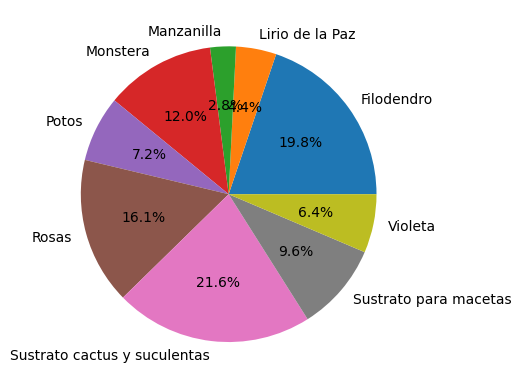

In [27]:
plt.pie(df2["ventas total"], labels=df2["producto"], autopct="%1.1f%%")
plt.show()